In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast


In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/one_test")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
results_df["new_var"] = results_df["cost"].map(lambda x: np.array(ast.literal_eval(x))[:, 0].var())

/tmp/dcs-tmp.u1508153/ipykernel_675020/3028652752.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(bayes_df["new_var"][i], bayes_df["mean_cost"][i], label, ha='left', va='bottom')


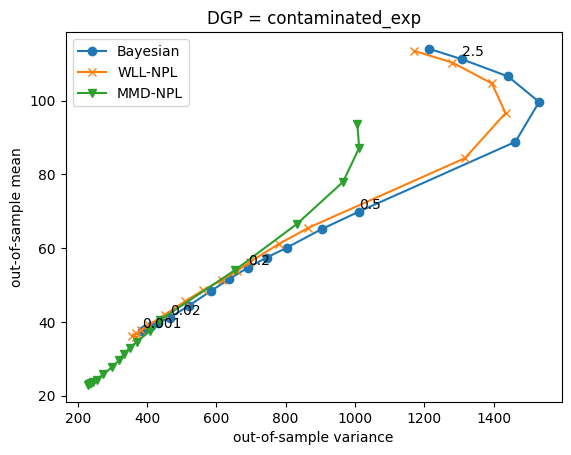

In [5]:
dgp = "contaminated_exp"
# dgp = "truncated_normal"
bayes_df = results_df.loc[(results_df["mean_cost"].notna()) & (results_df["posterior"] == "bayes") & (results_df["dgp"] == dgp)]
wll_df = results_df.loc[(results_df["mean_cost"].notna()) & (results_df["posterior"] == "wll") & (results_df["dgp"] == dgp)]
mmd_df = results_df.loc[(results_df["mean_cost"].notna()) & (results_df["posterior"] == "mmd") & (results_df["dgp"] == dgp)]

plt.plot(bayes_df["new_var"], bayes_df["mean_cost"], marker='o', label="Bayesian")
plt.plot(wll_df["new_var"], wll_df["mean_cost"], marker="x", label="WLL-NPL")
plt.plot(mmd_df["new_var"], mmd_df["mean_cost"], marker="v", label="MMD-NPL")

plt.title(f"DGP = {dgp}")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")
for i, label in enumerate(bayes_df["epsilon"]):
    if i % 4 == 0:
        plt.text(bayes_df["new_var"][i], bayes_df["mean_cost"][i], label, ha='left', va='bottom')
    # if (i+2) % 4 == 0:
    #     plt.text(npl_df["new_var"][i], npl_df["mean_cost"][i], label, ha='right', va='bottom')

In [4]:
results_df.loc[results_df["dgp"] == dgp][["epsilon", "mean_cost", "new_var", "posterior"]]

,epsilon,mean_cost,new_var,posterior
uuid,,,,
20399152-d325-476b-ad57-a1261929a52a,0.001,19.245659,155.926899,bayes
122afb28-c209-4a13-803a-e0ce763faeba,0.001,18.469455,144.873240,wll
1558158a-2d99-40ab-a453-30b50550fd7a,0.001,12.512219,114.011236,mmd
523c7bba-f1db-4646-b6af-e598083a4cb2,0.002,18.844259,152.154768,bayes
d9fb5dfa-fb85-4330-b210-3b12117b5c89,0.002,18.055055,141.138922,wll
83781dbe-f547-4a3c-9029-463859011de3,0.002,12.757463,121.094104,mmd
9fafa9f7-db9f-4b87-b200-4d46e568abaf,0.005,17.940059,145.713606,bayes
86b9b905-3d5a-4592-bb45-d94bbd50a1cf,0.005,17.222055,136.712801,wll
c9e77349-6b77-4d5e-a2f5-414fcec9caf6,0.005,12.434017,117.221092,mmd
